# 05 - Cluster Interpretation and Business Recommendations

**Phases 8 and 9.** Cluster indices become named segments with a strategy
attached. Names are derived from centroid *ranks*, never hard-coded to a
cluster number, so a re-run cannot scramble the narrative.

The dataset carries no income or wealth field, so every profile describes
observed purchasing behaviour and infers no affluence.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

from src import config as cfg, visuals as vz
from src.clustering import fit_kmeans, eta_squared, pca_projection
from src.preprocessing import FEATURE_SETS, build_matrix
from src.interpretation import (attach_segments, discriminating_features,
                                relative_profile, SEGMENT_LIBRARY)
vz.apply_style()
features = pd.read_csv(cfg.CLIENT_FEATURES)
X, names, _ = build_matrix(features, FEATURE_SETS['behaviour_wide'], 'standard')
labels = fit_kmeans(X, 4).labels_
segmented, profile, seg_names = attach_segments(features, labels)
print(seg_names)


{np.int32(3): 'Portfolio Accumulators', np.int32(0): 'Large-Format Premium Buyers', np.int32(2): 'Value-Tier Buyers', 1: 'Core Multi-Unit Investors'}


## Segment profiles

In [2]:
show = ['segment','n_clients','pct_clients','pct_capital','total_properties',
        'total_investment','avg_property_price','avg_floor_area',
        'purchase_span_days','office_share','age','satisfaction_score',
        'loan_flag','is_investment']
profile[show].round(3)


,segment,n_clients,pct_clients,pct_capital,total_properties,total_investment,avg_property_price,avg_floor_area,purchase_span_days,office_share,age,satisfaction_score,loan_flag,is_investment
cluster,,,,,,,,,,,,,,
0,Large-Format Premium Buyers,516,0.258,0.254,3.010,1239304.279,411771.248,1350.933,339.953,0.172,53.649,3.012,0.359,0.318
1,Core Multi-Unit Investors,766,0.383,0.451,4.117,1484830.697,361783.895,1194.188,448.248,0.143,55.364,3.048,0.362,0.295
2,Value-Tier Buyers,679,0.340,0.255,3.384,947861.857,281833.931,941.890,382.891,0.138,55.476,3.000,0.381,0.312
3,Portfolio Accumulators,39,0.020,0.040,7.692,2571575.353,338826.795,1117.600,552.487,0.134,62.513,3.385,0.385,0.333


In [3]:
print("Each segment's mean as a multiple of the overall mean (1.00 = average):")
relative_profile(profile, features).round(2)


Each segment's mean as a multiple of the overall mean (1.00 = average):


,segment,total_properties,total_investment,avg_property_price,max_property_price,price_dispersion,avg_floor_area,total_area,avg_price_per_sqft,unique_towers,active_months,purchase_span_days,office_share,apartment_share,age,satisfaction_score,loan_flag,is_investment,is_company,is_domestic
cluster,,,,,,,,,,,,,,,,,,,,
0,Large-Format Premium Buyers,0.82,0.98,1.19,1.11,1.06,1.18,0.98,1.01,0.83,0.83,0.85,1.15,0.97,0.97,0.99,0.97,1.03,1.05,0.98
1,Core Multi-Unit Investors,1.13,1.18,1.04,1.09,1.14,1.04,1.18,1.00,1.13,1.12,1.12,0.96,1.01,1.00,1.01,0.98,0.96,1.01,1.04
2,Value-Tier Buyers,0.93,0.75,0.81,0.81,0.80,0.82,0.76,0.99,0.94,0.93,0.96,0.93,1.01,1.01,0.99,1.04,1.02,0.97,0.97
3,Portfolio Accumulators,2.11,2.04,0.98,1.11,1.02,0.97,2.04,1.00,1.83,1.96,1.38,0.90,1.02,1.13,1.12,1.05,1.08,0.50,1.07


In [4]:
print("What separates the segments (range of segment means, in overall SD):")
display(discriminating_features(profile, features, top_n=10).round(2))
print()
print("Variance explained by the segmentation, per feature:")
e = eta_squared(features, labels, ['total_properties','total_investment',
    'avg_property_price','avg_floor_area','total_area','unique_towers',
    'purchase_span_days','office_share','age','satisfaction_score',
    'loan_flag','is_investment','is_company','is_domestic'])
print(e.sort_values(ascending=False).round(3).to_string())


What separates the segments (range of segment means, in overall SD):


,feature,spread_in_sd
0,total_properties,5.58
1,unique_towers,5.11
2,active_months,4.78
3,total_area,4.71
4,total_investment,4.67
5,avg_property_price,1.86
6,avg_floor_area,1.86
7,max_property_price,1.52
8,purchase_span_days,1.32
9,price_dispersion,0.87



Variance explained by the segmentation, per feature:


total_properties      0.755
unique_towers         0.736
total_area            0.715
total_investment      0.712
avg_property_price    0.537
avg_floor_area        0.535
purchase_span_days    0.091
age                   0.006
office_share          0.005
is_domestic           0.004
satisfaction_score    0.001
is_investment         0.001
loan_flag             0.000
is_company            0.000


Behavioural features are explained at 0.4-0.8; every declared attribute sits
near 0.00. The segmentation is a description of purchasing behaviour, and it
deliberately says nothing about demographics - because in this dataset
demographics say nothing about purchasing.


## Visual summary

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


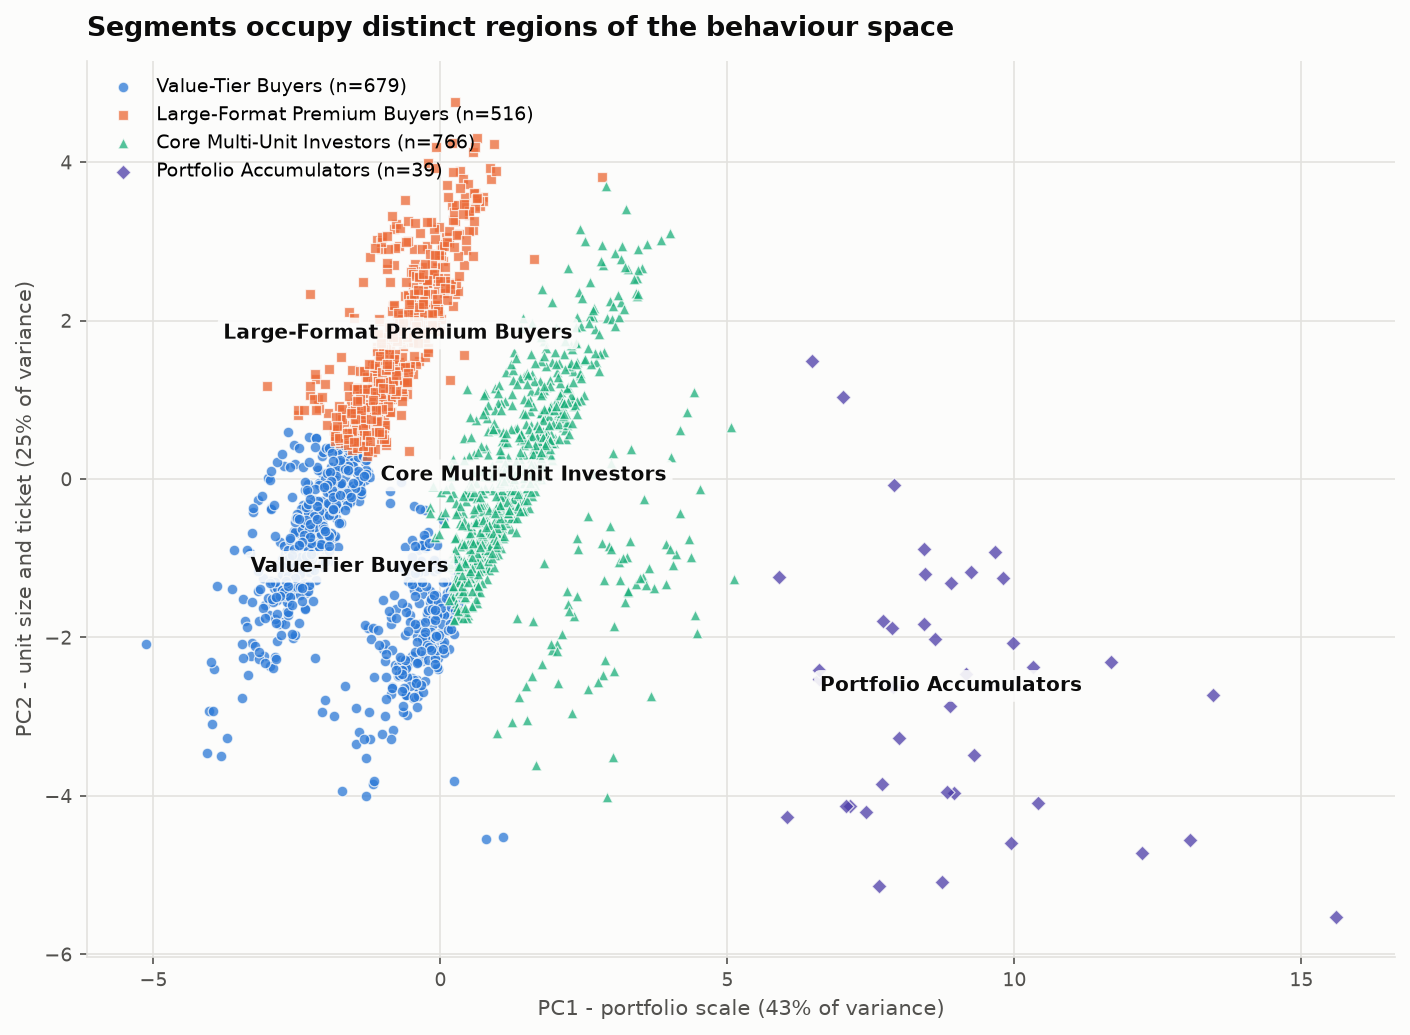

findfont: Failed to find font weight 600, now using 700.


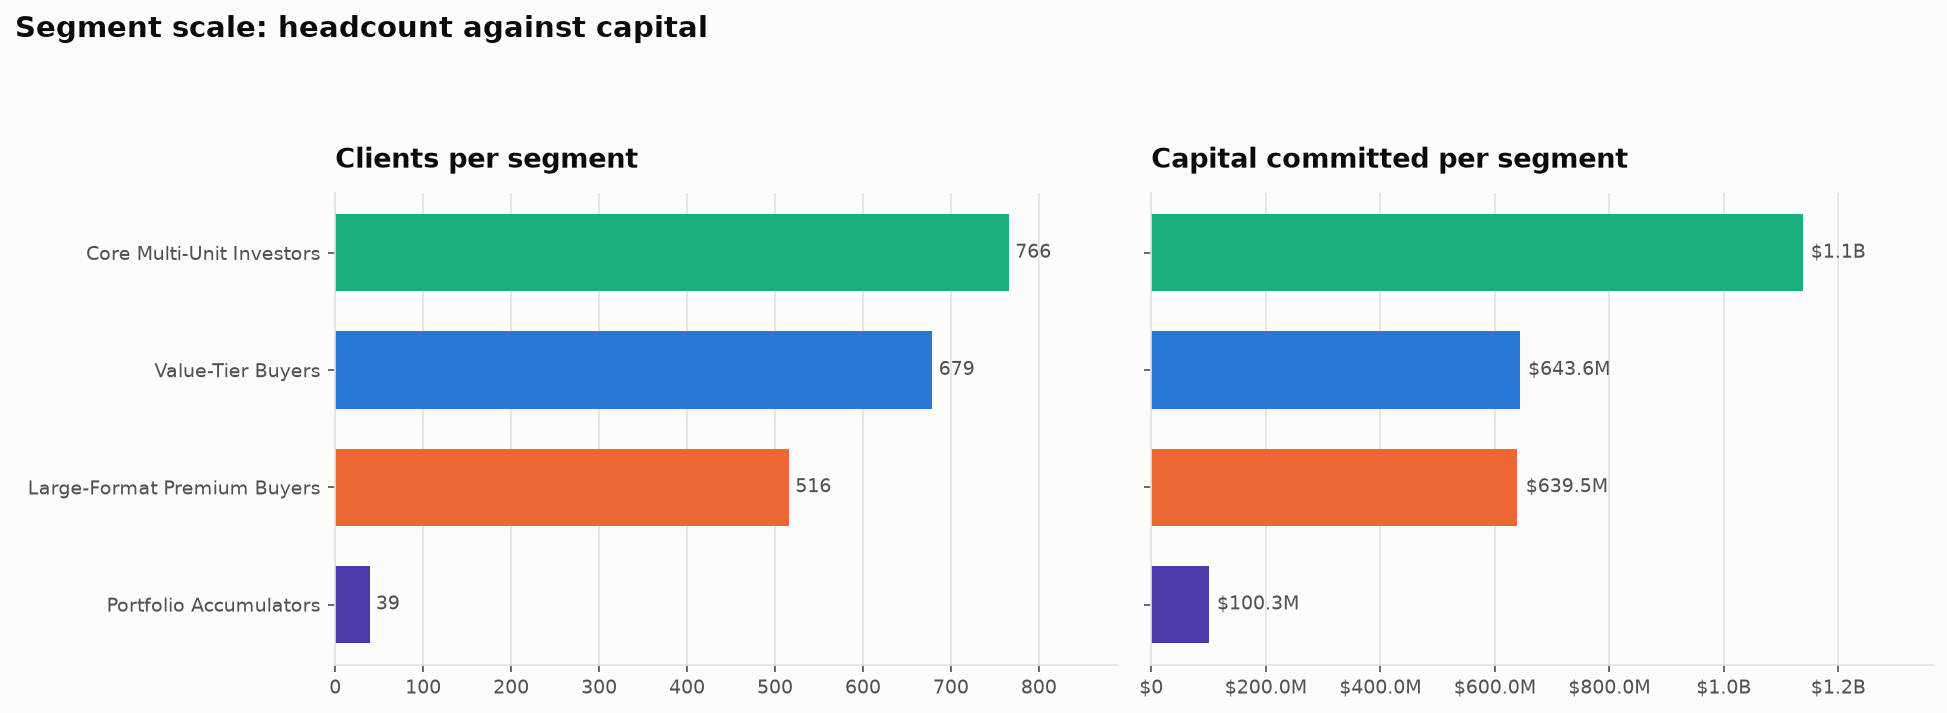

findfont: Failed to find font weight 600, now using 700.


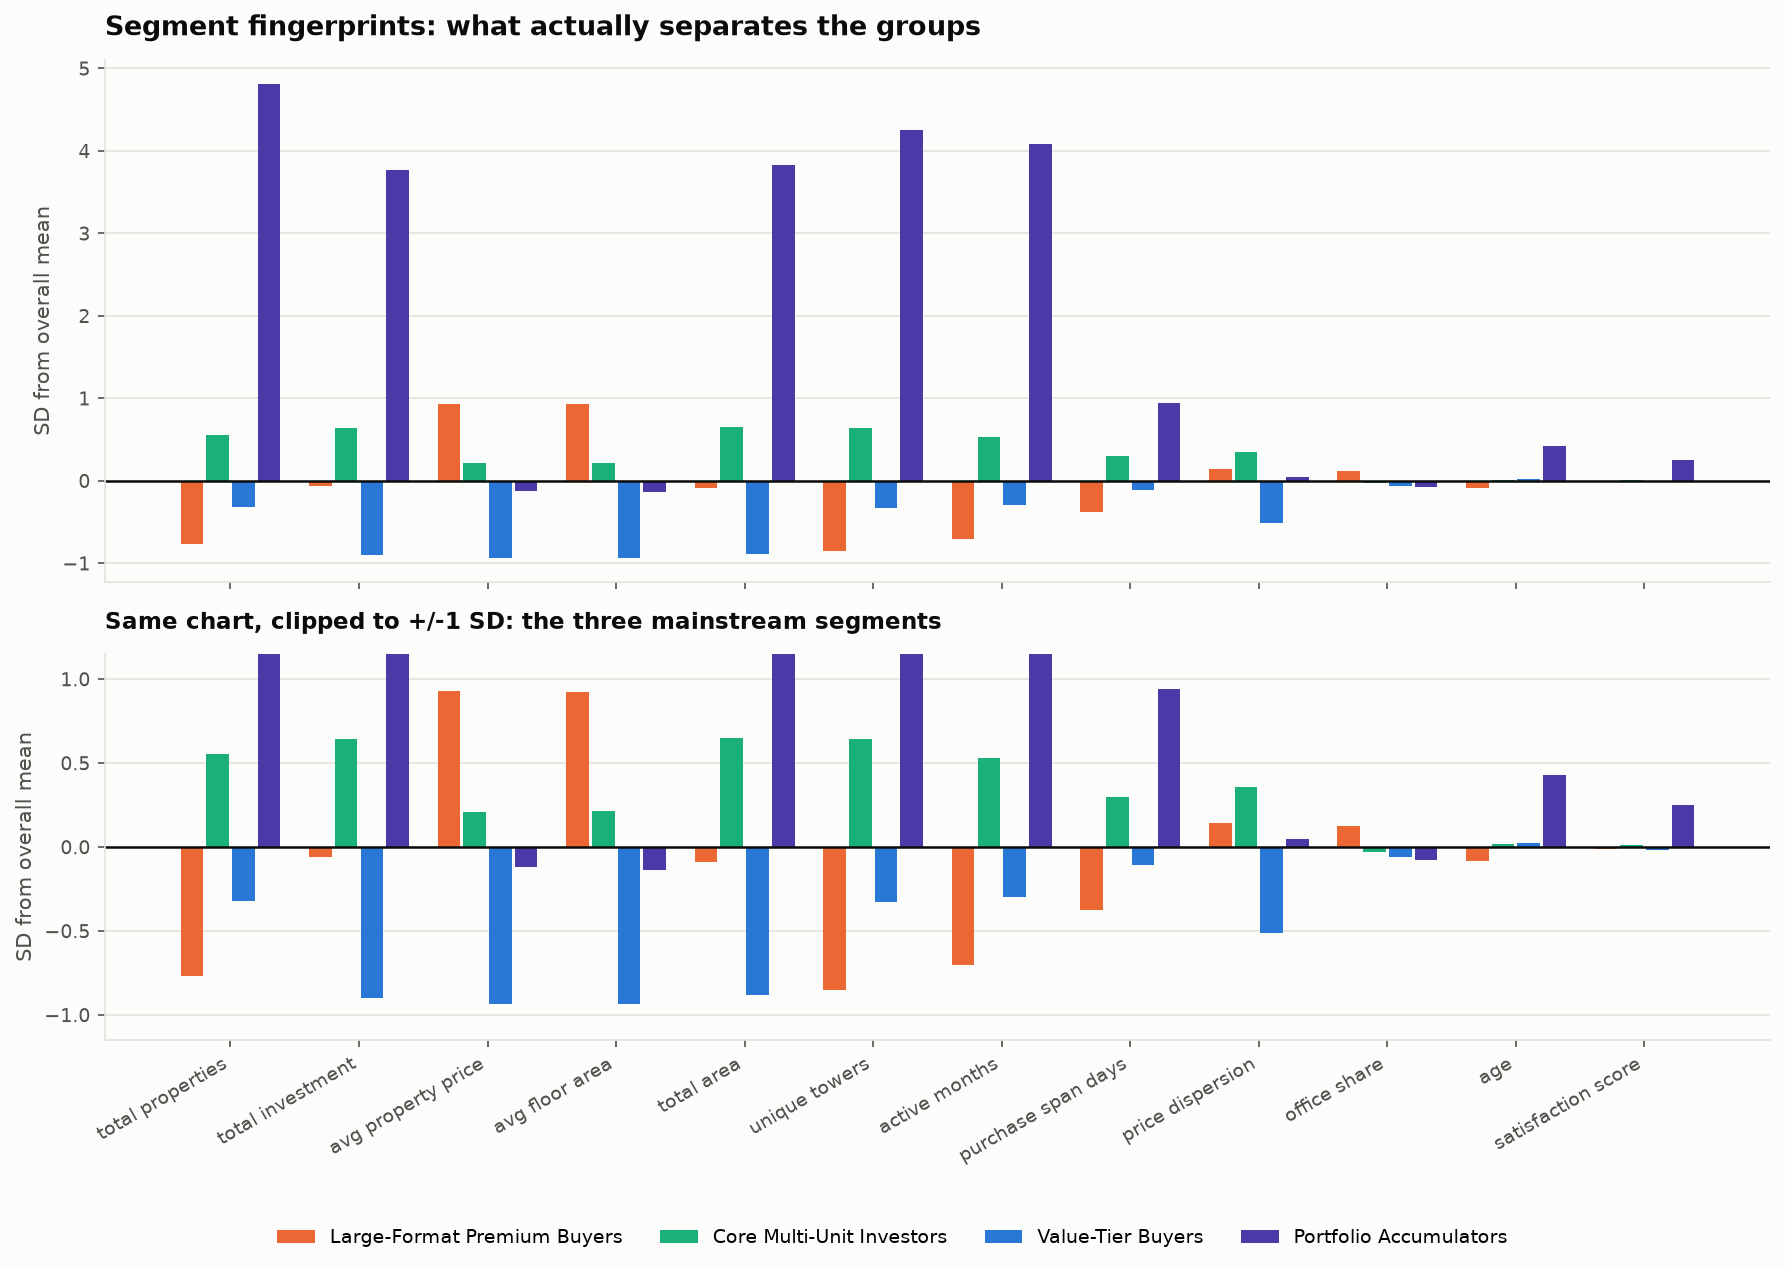

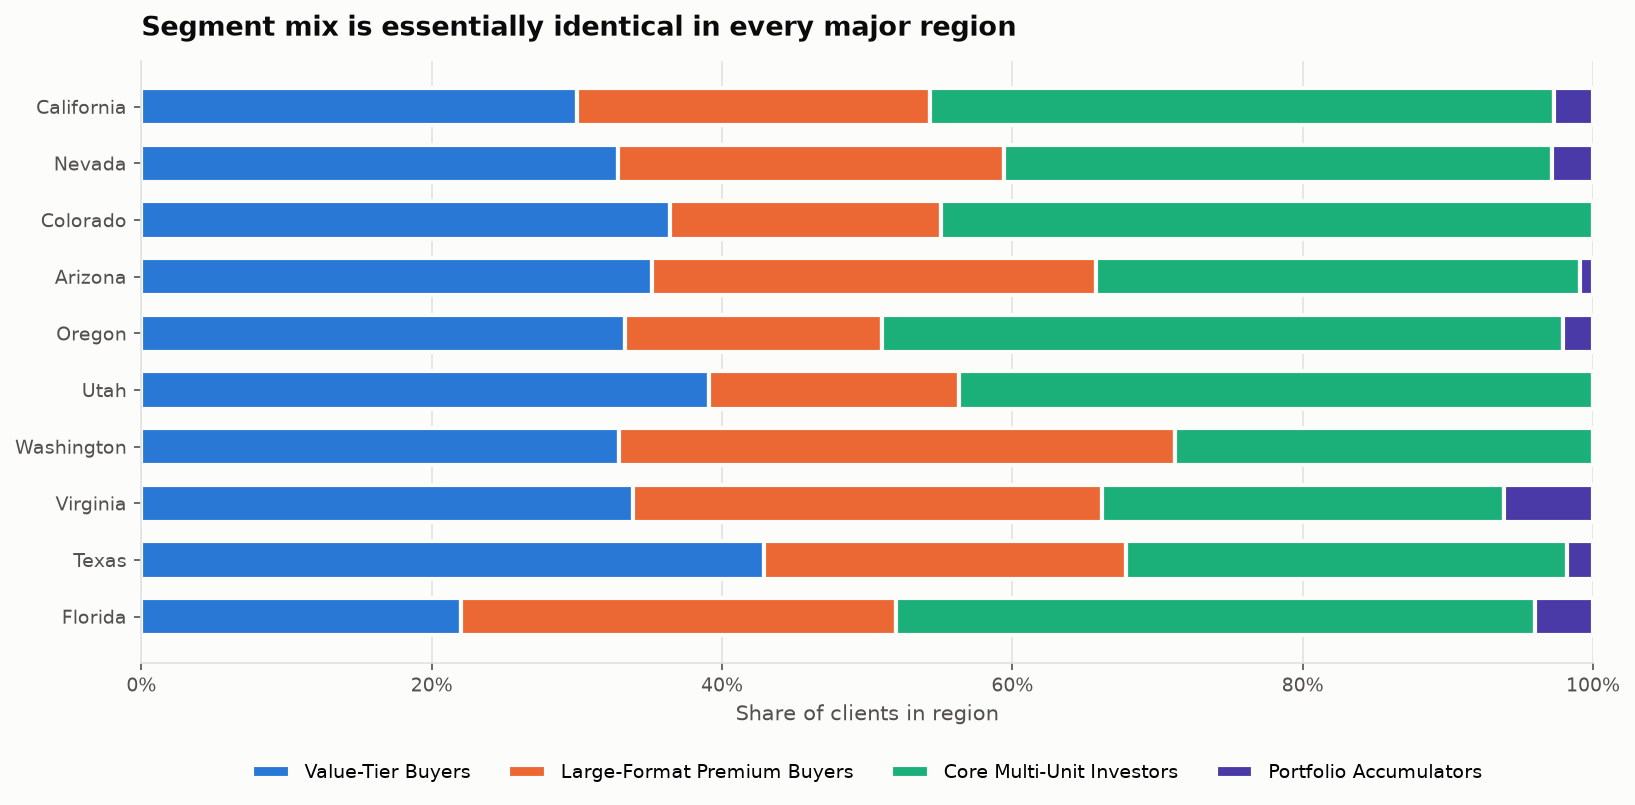

In [5]:
from IPython.display import Image, display as disp
coords, pca = pca_projection(X, 2)
disp(Image(str(vz.fig_pca_scatter(coords, labels, seg_names, pca))))
disp(Image(str(vz.fig_segment_sizes(profile))))
FINGERPRINT = ['total_properties','total_investment','avg_property_price',
               'avg_floor_area','total_area','unique_towers','active_months',
               'purchase_span_days','price_dispersion','office_share',
               'age','satisfaction_score']
disp(Image(str(vz.fig_segment_fingerprint(profile, features, FINGERPRINT))))
disp(Image(str(vz.fig_segment_geography(segmented))))


## Business recommendations

In [6]:
for cl in profile.index:
    seg = profile.loc[cl, 'segment']
    info = SEGMENT_LIBRARY.get(seg, {})
    print("=" * 74)
    print(f"{seg}   |   {int(profile.loc[cl,'n_clients'])} clients "
          f"({profile.loc[cl,'pct_clients']:.1%} of book, "
          f"{profile.loc[cl,'pct_capital']:.1%} of capital)")
    print("=" * 74)
    print("  Defining thesis :", info.get('thesis',''))
    print("  Primary signal  :", info.get('signal',''))
    print("  Strategy        :", info.get('strategy',''))
    print()


Large-Format Premium Buyers   |   516 clients (25.8% of book, 25.4% of capital)
  Defining thesis : Fewest units of any segment, but the largest floor areas and the highest price per transaction. Buys selectively and concludes quickly.
  Primary signal  : Ticket size and unit footprint, not frequency.
  Strategy        : Lead with penthouse and large-floorplate inventory, fit-out and customisation options, and concierge handover. Frequency campaigns are wasted here.

Core Multi-Unit Investors   |   766 clients (38.3% of book, 45.1% of capital)
  Defining thesis : Above-average unit count at a mid-market ticket, with the second-longest buying window. The volume engine of the book.
  Primary signal  : Steady accumulation at mainstream price points.
  Strategy        : Nurture toward the accumulator tier with multi-unit incentives, staged-purchase plans and loyalty pricing on the third and subsequent units.

Value-Tier Buyers   |   679 clients (34.0% of book, 25.5% of capital)
  Defining 